In [2]:
import numpy as np
import h5py
from astropy.cosmology import WMAP9 as cosmo
import galsim
import matplotlib.pyplot as plt
#!/usr/bin/env python
# coding: utf-8

# # Simulating different telescopes
# This notebooks provides examples in how to use the lenstronomy.SimulationAPI modules in simulating (realistic) mock lenses taylored to a specific observation and instrument and makes a montage of different telescope settings currently available.
# 
# The module enables to use the astronomical magnitude conventions and can translate those into the lenstronomy core module configurations.

# In[1]:


import copy
import h5py
import os
import numpy as np
import scipy
import sncosmo
from PIL import Image
import galsim
from astropy.cosmology import WMAP9 as cosmo
import matplotlib.pyplot as plt

from astropy.table import Table
# # make sure lenstronomy is installed, otherwise install the latest pip version
# try:
#     import lenstronomy
# except:
#     get_ipython().system('pip install lenstronomy')
from astropy.io import fits
from astropy import wcs
import galsim

# lenstronomy module import
from lenstronomy.Util import image_util, data_util, util
import lenstronomy.Plots.plot_util as plot_util
from lenstronomy.SimulationAPI.sim_api import SimAPI
from lenstronomy.Plots.plot_util import coordinate_arrows, scale_bar
from lenstronomy.SimulationAPI.point_source_variability import PointSourceVariability

from astropy.table import Table
import sncosmo

import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter
from lenstronomy.Cosmo.micro_lensing import einstein_radius

In [3]:
def var_func(time, zero_point, band, z_source): #band either desg, desi, desr
    if z_source > 0.915:
        z_source = 0.915
    
    obs = Table({'time': [time],
             'band': [band],          #filters we are observing in
             'gain': [1.],              #dw
             'skynoise': [0],           #depends on exposure time, but will be addig noise later in lenstronomy, could set to 0
             'zp': [zero_point],        # zero point, what corresponds to 0 flux in this image - pixel values to magnitudes
             'zpsys':['ab']})           # ab magnitudes, units of zero point

    model = sncosmo.Model(source='salt2')
    params = {'z': 0, 't0': 56200.0, 'x0':1.e-5, 'x1': 0.1, 'c': -0.1}

    lcs = sncosmo.realize_lcs(obs, model, [params])
    flux = np.array(lcs[0]['flux'])
    # print(lcs[0]['time'])
    # print(flux)
    zero_points = np.array(obs['zp'])
    magnitude = zero_points - 2.5 * np.log10(flux)
    # print(time,magnitude)
    return magnitude

var_func_g = lambda t: var_func(t, 28.30, 'lsstg', z_source)
var_func_r = lambda t: var_func(t, 28.13, 'lsstr', z_source)
var_func_i = lambda t: var_func(t, 27.7, 'lssti', z_source)


In [4]:
def simulate_rgb(ConfigList, size, kwargs_numerics, time, source_x=0,source_y=0,returnsqrt = False):
    band_g, band_r, band_i = ConfigList
    kwargs_i_band = band_i.kwargs_single_band()
    kwargs_g_band = band_g.kwargs_single_band()
    kwargs_r_band = band_r.kwargs_single_band()
    #print(kwargs_b_band) #'pixel_scale' : kwargs_b_band['pixel_scale']
    # set number of pixels from pixel scale
    pixel_scale = kwargs_g_band['pixel_scale']
    numpix = int(round(size / pixel_scale))
    #kwargs_model['pixel_scale'] = kwargs_b_band['pixel_scale']
    sim_i = SimAPI(numpix=numpix, kwargs_single_band=kwargs_i_band, kwargs_model=kwargs_model_time_var)
    sim_g = SimAPI(numpix=numpix, kwargs_single_band=kwargs_g_band, kwargs_model=kwargs_model_time_var)
    sim_r = SimAPI(numpix=numpix, kwargs_single_band=kwargs_r_band, kwargs_model=kwargs_model_time_var)

    # return the ImSim instance. With this class instance, you can compute all the
    # modelling accessible of the core modules. See class documentation and other notebooks.
    imSim_i = sim_i.image_model_class(kwargs_numerics)
    imSim_g = sim_g.image_model_class(kwargs_numerics)
    imSim_r = sim_r.image_model_class(kwargs_numerics)


    # turn magnitude kwargs into lenstronomy kwargs
    kwargs_lens_light_g, kwargs_source_g, kwargs_ps_g = sim_g.magnitude2amplitude(kwargs_lens_light_mag_g, kwargs_source_mag_g, kwargs_ps_mag_g)
    kwargs_lens_light_r, kwargs_source_r, kwargs_ps_r = sim_g.magnitude2amplitude(kwargs_lens_light_mag_r, kwargs_source_mag_r, kwargs_ps_mag_r)
    kwargs_lens_light_i, kwargs_source_i, kwargs_ps_i = sim_r.magnitude2amplitude(kwargs_lens_light_mag_i, kwargs_source_mag_i, kwargs_ps_mag_i)

   

    
    # ps_var_g = PointSourceVariability(source_x, source_y, var_func_g, numpix, kwargs_g_band, kwargs_model_time_var, kwargs_numerics,
    #              kwargs_lens, kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=kwargs_ps_mag_g)

    # ps_var_r = PointSourceVariability(source_x, source_y, var_func_r, numpix, kwargs_r_band, kwargs_model_time_var, kwargs_numerics,
    #              kwargs_lens, kwargs_source_mag_r, kwargs_lens_light_mag_r, kwargs_ps_mag=kwargs_ps_mag_r)

    # ps_var_i = PointSourceVariability(source_x, source_y, var_func_i, numpix, kwargs_i_band, kwargs_model_time_var, kwargs_numerics,
    #              kwargs_lens, kwargs_source_mag_i, kwargs_lens_light_mag_i, kwargs_ps_mag=kwargs_ps_mag_i)

    try:
        ps_var_g = PointSourceVariability(source_x, source_y, var_func_g, numpix, kwargs_g_band, 
                                          kwargs_model_time_var, kwargs_numerics, kwargs_lens, 
                                          kwargs_source_mag_g, kwargs_lens_light_mag_g, kwargs_ps_mag=kwargs_ps_mag_g)
        ps_var_r = PointSourceVariability(source_x, source_y, var_func_r, numpix, kwargs_r_band, 
                                          kwargs_model_time_var, kwargs_numerics, kwargs_lens, 
                                          kwargs_source_mag_r, kwargs_lens_light_mag_r, kwargs_ps_mag=kwargs_ps_mag_r)
        ps_var_i = PointSourceVariability(source_x, source_y, var_func_i, numpix, kwargs_i_band, 
                                          kwargs_model_time_var, kwargs_numerics, kwargs_lens, 
                                          kwargs_source_mag_i, kwargs_lens_light_mag_i, kwargs_ps_mag=kwargs_ps_mag_i)
    except ValueError as e:
        if 'zero-size array to reduction operation minimum' in str(e):
            print("No arrival times computed. Check lens parameters and source position.")
            # Optionally handle this case by setting defaults or skipping further processing
            return None, None, None, None
        else:
            raise
    
    delays = ps_var_g.delays
    # print('DELAYS',delays,np.max(delays))
    max_delays = np.max(delays)
    n_delays = len(delays)

    image_g = ps_var_g.image_time(time=time)#imSim_b.image(kwargs_lens, kwargs_source_g, kwargs_lens_light_g, kwargs_ps_g)
    image_r = ps_var_r.image_time(time=time)#imSim_g.image(kwargs_lens, kwargs_source_r, kwargs_lens_light_r, kwargs_ps_r)
    image_i = ps_var_i.image_time(time=time)#imSim_r.image(kwargs_lens, kwargs_source_i, kwargs_lens_light_i, kwargs_ps_i)

    # add noise
    image_i += sim_i.noise_for_model(model=image_i)
    image_g += sim_g.noise_for_model(model=image_g)
    image_r += sim_r.noise_for_model(model=image_r)

    # and plot it

    img = np.zeros((image_g.shape[0], image_g.shape[1], 3), dtype=float)
    #scale_max=10000
    def _scale_max(image): 
        flat=image.flatten()
        flat.sort()
        scale_max = flat[int(len(flat)*0.95)]
        return scale_max
    if returnsqrt==True:
        img[:,:,0] = plot_util.sqrt(image_g, scale_min=0, scale_max=_scale_max(image_g))
        img[:,:,1] = plot_util.sqrt(image_r, scale_min=0, scale_max=_scale_max(image_r))
        img[:,:,2] = plot_util.sqrt(image_i, scale_min=0, scale_max=_scale_max(image_i))
    else:
        img[:,:,0] = image_i
        img[:,:,1] = image_g
        img[:,:,2] = image_r
        
    data_class = sim_i.data_class
    # #print(sim_r.psf_class.fwhm)
    # psf_i = sim_i.psf_class.kernel_point_source
    # psf_g = sim_g.psf_class.kernel_point_source
    # psf_r = sim_r.psf_class.kernel_point_source
    # psf = np.stack((psf_i,psf_g,psf_r))
    return img, data_class, max_delays, n_delays



In [5]:
nbands = 3
nepochs = 15
bands = ['lsstg', 'lsstr', 'lssti']

times = [56210]

# ## Define camera and observations
# As an example, we define the camera and observational settings of a LSST-like observation. We define one camera setting and three different observations corresponding to g,r,i imaging.
# 
# For the complete list of possible settings, we refer to the SimulationAPI.observation_api classes. There are pre-configured settings which approximately mimic observations from current and future instruments. Be careful using those and check whether they are sufficiently accurate for your specific science case!

# In[3]:


# Instrument setting from pre-defined configurations

from lenstronomy.SimulationAPI.ObservationConfig.DES import DES
#from lenstronomy.SimulationAPI.ObservationConfig.LSSTsingleobs import LSST
from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST

from lenstronomy.SimulationAPI.ObservationConfig.Euclid import Euclid
from lenstronomy.SimulationAPI.ObservationConfig.Roman import Roman

DES_g = DES(band='g', psf_type='GAUSSIAN', coadd_years=3)
DES_r = DES(band='r', psf_type='GAUSSIAN', coadd_years=3)
DES_i = DES(band='i', psf_type='GAUSSIAN', coadd_years=3)
des = [DES_g, DES_r, DES_i]

LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
lsst = [LSST_g, LSST_r, LSST_i]


Roman_g = Roman(band='F062', psf_type='PIXEL', survey_mode='wide_area')
Roman_r = Roman(band='F106', psf_type='PIXEL', survey_mode='wide_area')
Roman_i = Roman(band='F184', psf_type='PIXEL', survey_mode='wide_area')#'single_exposure')#'wide_area')
roman = [Roman_g, Roman_r, Roman_i]
LS4_g_band_obs = {'exposure_time': 15.,  # exposure time per image (in seconds)
                   'sky_brightness': 22.26,  # sky brightness (in magnitude per square arcseconds)
                   'magnitude_zero_point': 28.30,  # magnitude in which 1 count per second per arcsecond square is registered (in ADU's)
                   'num_exposures': 30,  # number of exposures that are combined
                   'seeing': 1.5,  # full width at half maximum of the PSF (if not specific psf_model is specified)
                   'psf_type': 'GAUSSIAN',  # string, type of PSF ('GAUSSIAN' and 'PIXEL' supported)
                   'kernel_point_source': None  # 2d numpy array, model of PSF centered with odd number of pixels per axis (optional when psf_type='PIXEL' is chosen)
                  }

LS4_r_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 21.2,
                   'magnitude_zero_point': 28.13,
                   'num_exposures': 30,
                   'seeing': 1.5,
                   'psf_type': 'GAUSSIAN'}

LS4_i_band_obs = {'exposure_time': 15.,
                   'sky_brightness': 20.48,
                   'magnitude_zero_point': 27.79,
                   'num_exposures': 30,
                   'seeing': 1.5,
                   'psf_type': 'GAUSSIAN'}

LS4_camera = {'read_noise': 10,  # std of noise generated by read-out (in units of electrons)
               'pixel_scale': 1.0,  # scale (in arcseonds) of pixels
               'ccd_gain': 4.5  # electrons/ADU (analog-to-digital unit). A gain of 8 means that the camera digitizes the CCD signal so that each ADU corresponds to 8 photoelectrons.
              }
# lenstronomy provides these setting to be imported with the SimulationAPI.ObservationConfig routines.

kwargs_g_band_LS4 = util.merge_dicts(LS4_camera, LS4_g_band_obs)
kwargs_r_band_LS4 = util.merge_dicts(LS4_camera, LS4_r_band_obs)
kwargs_i_band_LS4 = util.merge_dicts(LS4_camera, LS4_i_band_obs)
kwargs_LS4 = [kwargs_g_band_LS4,kwargs_r_band_LS4,kwargs_i_band_LS4]


# import NGC1300 jpg image and decompose it
import imageio.v2 as imageio
from scipy.ndimage import gaussian_filter
from lenstronomy.Cosmo.micro_lensing import einstein_radius
# find path to data
path = os.getcwd()
dirpath, _ = os.path.split(path)
module_path, _ = os.path.split(dirpath)

In [19]:
# read data, this only works if you execute this notebook within the environment of the github repo!
# ## Define model settings
# 
# The model settings are handled by the SimulationAPI.model_api ModelAPI class. 
# The role is to return instances of the lenstronomy LightModel, LensModel, PointSource modules according to the options chosen by the user. Currently, all other model choices are equivalent to the ones provided by LightModel, LensModel, PointSource.
# The current options of the class instance only describe a subset of possibilities and we refer to the specific class instances for details about all the possibilities.
# 
# For this example, we chose a single lens plane and a single source plane, elliptical Sersic profile for the deflector, the interpolated Galaxy as the source and an additional lensed point source.

# In[5]:


# ## Brightness definitions in magnitude space
# One core feature is the support of light profile amplitudes in astronomical magnitude space (at least for few selected well defined brightness profiles).
# 
# We first define all parameters in magnitude space and then use the SimAPI routine to translate the arguments into lenstronomy conventions used by the ImSim module. The second model of each light component we defined as 'INTERPOL', which sets an interpolation grid given an image. This can be used to past real galaxies as lenses or sources into lenstronomy.

# In[69]:

#ignore devide by 0 warning and astropy warning
import warnings
np.seterr(divide='ignore')  
warnings.filterwarnings("ignore", message="Astropy Cosmology is provided. Make sure your cosmology model is consistent with the cosmology_model argument.")


f = h5py.File('lsst-altsched-1a-lowz.h5','r')
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
simdataall = f['system']['block0_values'][()]
# print(simdataall[0],simitems)
rtest_source = [0.944, 0.766, 0.678, 0.967, 0.717]
rtest_lens = [0.410, 0.396, 0.344, 0.680, 0.056]
rtest_delays = [11.36, 9.07, 20.28, 1.82, 3.06]

rtest_source = [0.717]
rtest_lens = [0.056]
rtest_delays = [3.06]


#This is where I match to that table I provided by redshift. You'll want to replace this with a search for the time delay parameter and match by that!
indcatalog =[]
delay_catalog = []
for i in range(len(rtest_source)):
    indD = np.argwhere((np.abs(rtest_lens[i]-simdataall[:,7])<0.02)&(np.abs(rtest_source[i]-simdataall[:,6])<0.02))
    if i==0:
        indcatalog=indD[:,0]
        
    else:
        indcatalog = np.hstack((indcatalog,indD[:,0]))
    delay_catalog.extend([rtest_delays[i]] * len(indD))


for i, ind in enumerate(indcatalog):
    simdata=simdataall[ind]
    z_lens = simdata[simitems == "zl"][0]
    z_source = simdata[simitems == "zs"][0]
    # print('z les',z_lens,'z source',z_source)
    
    target_delay = delay_catalog[i]
    # print('Target max time delay: ', target_delay)
    
    kwargs_model_time_var = {'lens_model_list': ['SIE', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],#['INTERPOL'],  # list of extended source models to be used, here we used the interpolated real galaxy
                'point_source_model_list': ['SOURCE_POSITION'],  # list of point source models to be used
                'z_lens': z_lens, 
                         'z_source': z_source
    } 
    Dl = cosmo.angular_diameter_distance(simdata[simitems == "zl"][0]).value
    Ds = cosmo.angular_diameter_distance(simdata[simitems == "zs"][0]).value
    Dls = cosmo.angular_diameter_distance_z1z2(simdata[simitems == "zl"][0],simdata[simitems == "zs"][0]).value
 
    theta_E_sim = simdata[simitems == "theta_e"][0]
    lens_reff = simdata[simitems == "lensgal_reff"][0]
    lens_n = simdata[simitems == "lensgal_n"][0]
    lens_theta = simdata[simitems == "lensgal_theta"][0]
    lens_ellip = simdata[simitems == "lensgal_ellip"][0]
    s = galsim.Shear(e=lens_ellip, beta=lens_theta*galsim.degrees)
    lens_e1 = s.e1
    lens_e2 = s.e2
   
    lens_gamma = simdata[simitems == "gamma"][0]
    gamma_theta = simdata[simitems == "theta_gamma"][0]
    lens_g1 = np.sin(gamma_theta*np.pi/180)*lens_gamma
    lens_g2 = np.cos(gamma_theta*np.pi/180)*lens_gamma
    lens_x = simdata[simitems == "lensgal_x"][0]
    lens_y = simdata[simitems == "lensgal_y"][0]

    host_reff = simdata[simitems == "host_reff"][0]
    host_n = simdata[simitems == "host_n"][0]
    host_theta = simdata[simitems == "host_theta"][0]
    host_ellip = simdata[simitems == "host_ellip"][0]
    try:
        sh = galsim.Shear(e=host_ellip, beta=host_theta*galsim.degrees)
    except:
        continue
    host_e1 = sh.e1
    host_e2 = sh.e2
    host_x = simdata[simitems == "host_x"][0]
    host_y = simdata[simitems == "host_y"][0]
    sn_x = simdata[simitems == "snx"][0]
    sn_y = simdata[simitems == "sny"][0]

    #My failed attempts to extract a meaningful magnitude from whatever units Danny was using
    '''
    lens_amp = 22.5-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])
    mu = -2.5*np.log(simdata[simitems == "lensgal_amplitude"][0])
    mag = mu - np.log10(2*np.pi*host_reff*60*60/180*np.pi*1e3)-36.57#mu - 5*np.log10(lens_reff/(Dl/60/60))-2.5*np.log10(2*np.pi)+10*np.log10(1+simdata[simitems == "zl"][0])
    print('MAG',mag,host_reff)
    print('VMAG',-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])-48.6)
    host_amp = 22.5-2.5*np.log10(simdata[simitems == "host_amplitude"][0])
    print(str(simitems),'lens_amp',lens_amp,'host_amp',host_amp,simdata[simitems == "lensgal_amplitude"][0])
    '''
    
    magdiff = 2.5*(np.log10(simdata[simitems == "lensgal_amplitude"][0])-np.log10(simdata[simitems == "host_amplitude"][0]))
   
    magdiffps = 2.5*(np.log10(simdata[simitems == "lensgal_amplitude"][0])-np.log10(simdata[simitems == "transient_amplitude"][0]))
  
    sig = simdata[simitems == "sigma"][0]
    theta_E = 4*np.pi*(sig/3e5)**2*Dls/Ds*180/np.pi*60*60
    M0=1.9*(sig/200)**5.1*1e8
    Mstar= 10**((np.log10(M0)-7.45)/1.05)*1e11
 
    radius = einstein_radius(Mstar, Dl*1e6, Ds*1e6)

    kwargs_lens = [
        {'theta_E': theta_E, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y},  # SIE model
        {'gamma1': lens_g1, 'gamma2': lens_g2, 'ra_0': 0, 'dec_0': 0}  # SHEAR model
    ]
    # lens light
    kwargs_lens_light_mag_g = [{'magnitude': 23, 'R_sersic': lens_reff, 'n_sersic': lens_n, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y}]
    # source light
    kwargs_source_mag_g = [{'magnitude': 23, 'R_sersic': host_reff, 'n_sersic': host_n, 'e1': host_e1, 'e2': host_e2, 'center_x': host_x, 'center_y': host_y}]
    # point source
    kwargs_ps_mag_g = [{'magnitude': 23, 'ra_source': sn_x, 'dec_source': sn_y}]    # and now we define the colors of the other two bands

    # r-band
    g_r_source = 1  # color mag_g - mag_r for source
    g_r_lens = -1  # color mag_g - mag_r for lens light
    g_r_ps = 0
    kwargs_lens_light_mag_r = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_r[0]['magnitude'] -= g_r_lens

    kwargs_source_mag_r = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_r[0]['magnitude'] -= g_r_source

    kwargs_ps_mag_r = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_r[0]['magnitude'] -= g_r_ps


    # i-band
    g_i_source = 2
    g_i_lens = -2
    g_i_ps = 0
    kwargs_lens_light_mag_i = copy.deepcopy(kwargs_lens_light_mag_g)
    kwargs_lens_light_mag_i[0]['magnitude'] -= g_i_lens

    kwargs_source_mag_i = copy.deepcopy(kwargs_source_mag_g)
    kwargs_source_mag_i[0]['magnitude'] -= g_i_source

    kwargs_ps_mag_i = copy.deepcopy(kwargs_ps_mag_g)
    kwargs_ps_mag_i[0]['magnitude'] -= g_i_ps


    # here we define the numerical options used in the ImSim module. 
    # Have a look at the ImageNumerics class for detailed descriptions.
    # If not further specified, the default settings are used.
    kwargs_numerics = {'point_source_supersampling_factor': 1}

    # Hack hard coded solution to get out PSF on line 52 of ~/.conda/envs/scarlet/lib/python3.10/site-packages/lenstronomy/Data/psf.py 
    #to get out PSF image!
    size = 6. # width of the image in units of arc seconds

    
    dist_lens_sn = np.sqrt((lens_x - sn_x)**2 + (lens_y - sn_y)**2)
    dist_lens_host = np.sqrt((lens_x - host_x)**2 + (lens_y - host_y)**2)

    for indt,time in enumerate(times):
        
        img_lsst, coords_lss, max_delay, n_delays = simulate_rgb(lsst, size=size, kwargs_numerics=kwargs_numerics,time=time,source_x=sn_x,source_y=sn_y,returnsqrt=False)
        if img_lsst is None:
            print("No time delay, simulation failed for time =", time)
            continue  
        else:
            if (np.abs(max_delay - target_delay) < 1) and n_delays == 2 and dist_lens_host> 0.5 and dist_lens_sn>0.5:
                print('Index: ', ind)
                print('Target delay: ', target_delay)
                print('Max delay: ', max_delay)
                print('N delays: ', n_delays)
                print('z lens',z_lens,'z source',z_source)
                print(time)
        

/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


Index:  14372
Target delay:  3.06
Max delay:  3.391408853330769
N delays:  2
z lens 0.03960798979698842 z source 0.7339256984421844
56210


/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


No arrival times computed. Check lens parameters and source position.
No time delay, simulation failed for time = 56210
Index:  26669
Target delay:  3.06
Max delay:  3.22748780125707
N delays:  2
z lens 0.03645272803807451 z source 0.7149410402022551
56210


/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


Index:  72358
Target delay:  3.06
Max delay:  3.961944864888022
N delays:  2
z lens 0.03899047935058693 z source 0.7344597447566079
56210
Index:  72864
Target delay:  3.06
Max delay:  4.050721314667516
N delays:  2
z lens 0.04277879505058542 z source 0.7181402582452532
56210
No arrival times computed. Check lens parameters and source position.
No time delay, simulation failed for time = 56210
Index:  121689
Target delay:  3.06
Max delay:  3.149667707412097
N delays:  2
z lens 0.03665448952350475 z source 0.7346998367738522
56210
Index:  129107
Target delay:  3.06
Max delay:  3.9506889434126817
N delays:  2
z lens 0.04673168384110257 z source 0.7274798066248238
56210
No arrival times computed. Check lens parameters and source position.
No time delay, simulation failed for time = 56210


/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)
/tmp/ipykernel_3455739/1868791912.py:20: RuntimeWarning: invalid value encountered in log10
  magnitude = zero_points - 2.5 * np.log10(flux)


Index:  206054
Target delay:  3.06
Max delay:  3.838165454837008
N delays:  2
z lens 0.038317551069212065 z source 0.7167907741748969
56210
Index:  221212
Target delay:  3.06
Max delay:  3.9065170477991265
N delays:  2
z lens 0.04441875122506668 z source 0.699811089105202
56210


# Figure our h5py file

In [9]:
f = h5py.File('lsst-altsched-1a-lowz.h5','r')
# Print all groups and datasets recursively
def print_structure(name, obj):
    print(name, "(Group)" if isinstance(obj, h5py.Group) else "(Dataset)")

# f.visititems(print_structure)

def print_structure(name, obj):
    obj_type = "Group" if isinstance(obj, h5py.Group) else "Dataset"
    print(f"{name} ({obj_type})")

f.visititems(print_structure)


fitmod (Group)
fitmod/axis0 (Dataset)
fitmod/axis1 (Dataset)
fitmod/block0_items (Dataset)
fitmod/block0_values (Dataset)
image (Group)
image/axis0 (Dataset)
image/axis1 (Dataset)
image/block0_items (Dataset)
image/block0_values (Dataset)
image/block1_items (Dataset)
image/block1_values (Dataset)
observations (Group)
observations/axis0 (Dataset)
observations/axis1 (Dataset)
observations/block0_items (Dataset)
observations/block0_values (Dataset)
observations/block1_items (Dataset)
observations/block1_values (Dataset)
observations/block2_items (Dataset)
observations/block2_values (Dataset)
stacked (Group)
stacked/axis0 (Dataset)
stacked/axis1 (Dataset)
stacked/block0_items (Dataset)
stacked/block0_values (Dataset)
stacked/block1_items (Dataset)
stacked/block1_values (Dataset)
stacked/block2_items (Dataset)
stacked/block2_values (Dataset)
subdata (Group)
subdata/axis0 (Dataset)
subdata/axis1 (Dataset)
subdata/block0_items (Dataset)
subdata/block0_values (Dataset)
subdata/block1_items (Da

In [10]:
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
print(simitems)
simdataall = f['system']['block0_values'][()]
# print(simdataall.shape)
# print(len(simdataall[:, 0]))
# print(simdataall[0, 0])
# print(simdataall[0, 31])

# print(simdataall[1, 0])
# print(simdataall[1, 31])

# t0 = simdataall[:,0]
# t_found = simdataall[:,31]
# delta_t= t0 - t_found
# print(delta_t.shape)

# plt.hist(delta_t, bins = 100)
# plt.show()

['t0' 'sigma' 'gamma' 'e' 'theta_e' 'theta_gamma' 'zs' 'zl' 'snx' 'sny'
 'MB' 'transient_amplitude' 'ebvhost' 'ra' 'dec' 'ebvmw' 'weight' 'host_n'
 'host_ellip' 'host_reff' 'host_theta' 'host_amplitude' 'host_x' 'host_y'
 'lensgal_n' 'lensgal_ellip' 'lensgal_reff' 'lensgal_theta'
 'lensgal_amplitude' 'lensgal_x' 'lensgal_y' 't_found']


In [11]:
# Assuming simitems = array of column names in order
# and simdataall = 2D array of shape (n_samples, n_columns)

# First, convert simitems to a list for easy indexing
columns = simitems.tolist()

# Now extract each parameter by name
t0 = simdataall[:, columns.index('t0')]
sigma = simdataall[:, columns.index('sigma')]
gamma = simdataall[:, columns.index('gamma')]
e = simdataall[:, columns.index('e')]
theta_e = simdataall[:, columns.index('theta_e')]
theta_gamma = simdataall[:, columns.index('theta_gamma')]
zs = simdataall[:, columns.index('zs')]
zl = simdataall[:, columns.index('zl')]
snx = simdataall[:, columns.index('snx')]
sny = simdataall[:, columns.index('sny')]
MB = simdataall[:, columns.index('MB')]
transient_amplitude = simdataall[:, columns.index('transient_amplitude')]
ebvhost = simdataall[:, columns.index('ebvhost')]
ra = simdataall[:, columns.index('ra')]
dec = simdataall[:, columns.index('dec')]
ebvmw = simdataall[:, columns.index('ebvmw')]
weight = simdataall[:, columns.index('weight')]
host_n = simdataall[:, columns.index('host_n')]
host_ellip = simdataall[:, columns.index('host_ellip')]
host_reff = simdataall[:, columns.index('host_reff')]
host_theta = simdataall[:, columns.index('host_theta')]
host_amplitude = simdataall[:, columns.index('host_amplitude')]
host_x = simdataall[:, columns.index('host_x')]
host_y = simdataall[:, columns.index('host_y')]
lensgal_n = simdataall[:, columns.index('lensgal_n')]
lensgal_ellip = simdataall[:, columns.index('lensgal_ellip')]
lensgal_reff = simdataall[:, columns.index('lensgal_reff')]
lensgal_theta = simdataall[:, columns.index('lensgal_theta')]
lensgal_amplitude = simdataall[:, columns.index('lensgal_amplitude')]
lensgal_x = simdataall[:, columns.index('lensgal_x')]
lensgal_y = simdataall[:, columns.index('lensgal_y')]
t_found = simdataall[:, columns.index('t_found')]

In [12]:
print('MB[0]: ', MB[0])
print('transient_amplitude[0]: ', transient_amplitude[0])
print('host_amplitude[0]: ', host_amplitude[0])
print('lensgal_amplitude[0]: ', lensgal_amplitude[0])

MB[0]:  -19.302427626214108
transient_amplitude[0]:  1.284683700307726e-10
host_amplitude[0]:  3.745478989681849e-18
lensgal_amplitude[0]:  1.2037869946586042e-17


In [13]:
lens_amp = 22.5-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])
mu = -2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])
mag = mu - np.log10(2*np.pi*host_reff*60*60/180*np.pi*1e3)-36.57#mu - 5*np.log10(lens_reff/(Dl/60/60))-2.5*np.log10(2*np.pi)+10*np.log10(1+simdata[simitems == "zl"][0])
print('MAG',mag,host_reff)
print('VMAG',-2.5*np.log10(simdata[simitems == "lensgal_amplitude"][0])-48.6)
host_amp = 22.5-2.5*np.log10(simdata[simitems == "host_amplitude"][0])


MAG [-0.50012955 -1.14724777  0.11019507 ... -0.4706959  -0.51881
 -0.39794892] [0.30091201 1.33523512 0.07380995 ... 0.28119389 0.31413764 0.23782576]
VMAG -7.455330291805083


In [68]:
mag = mu - np.log10(2*np.pi*host_reff*60*60/180*np.pi*1e3)
print(mag)

[32.57852951 31.93141129 33.18885414 ... 32.60796316 32.55984906
 32.68071014]


## Make paper histogram plot

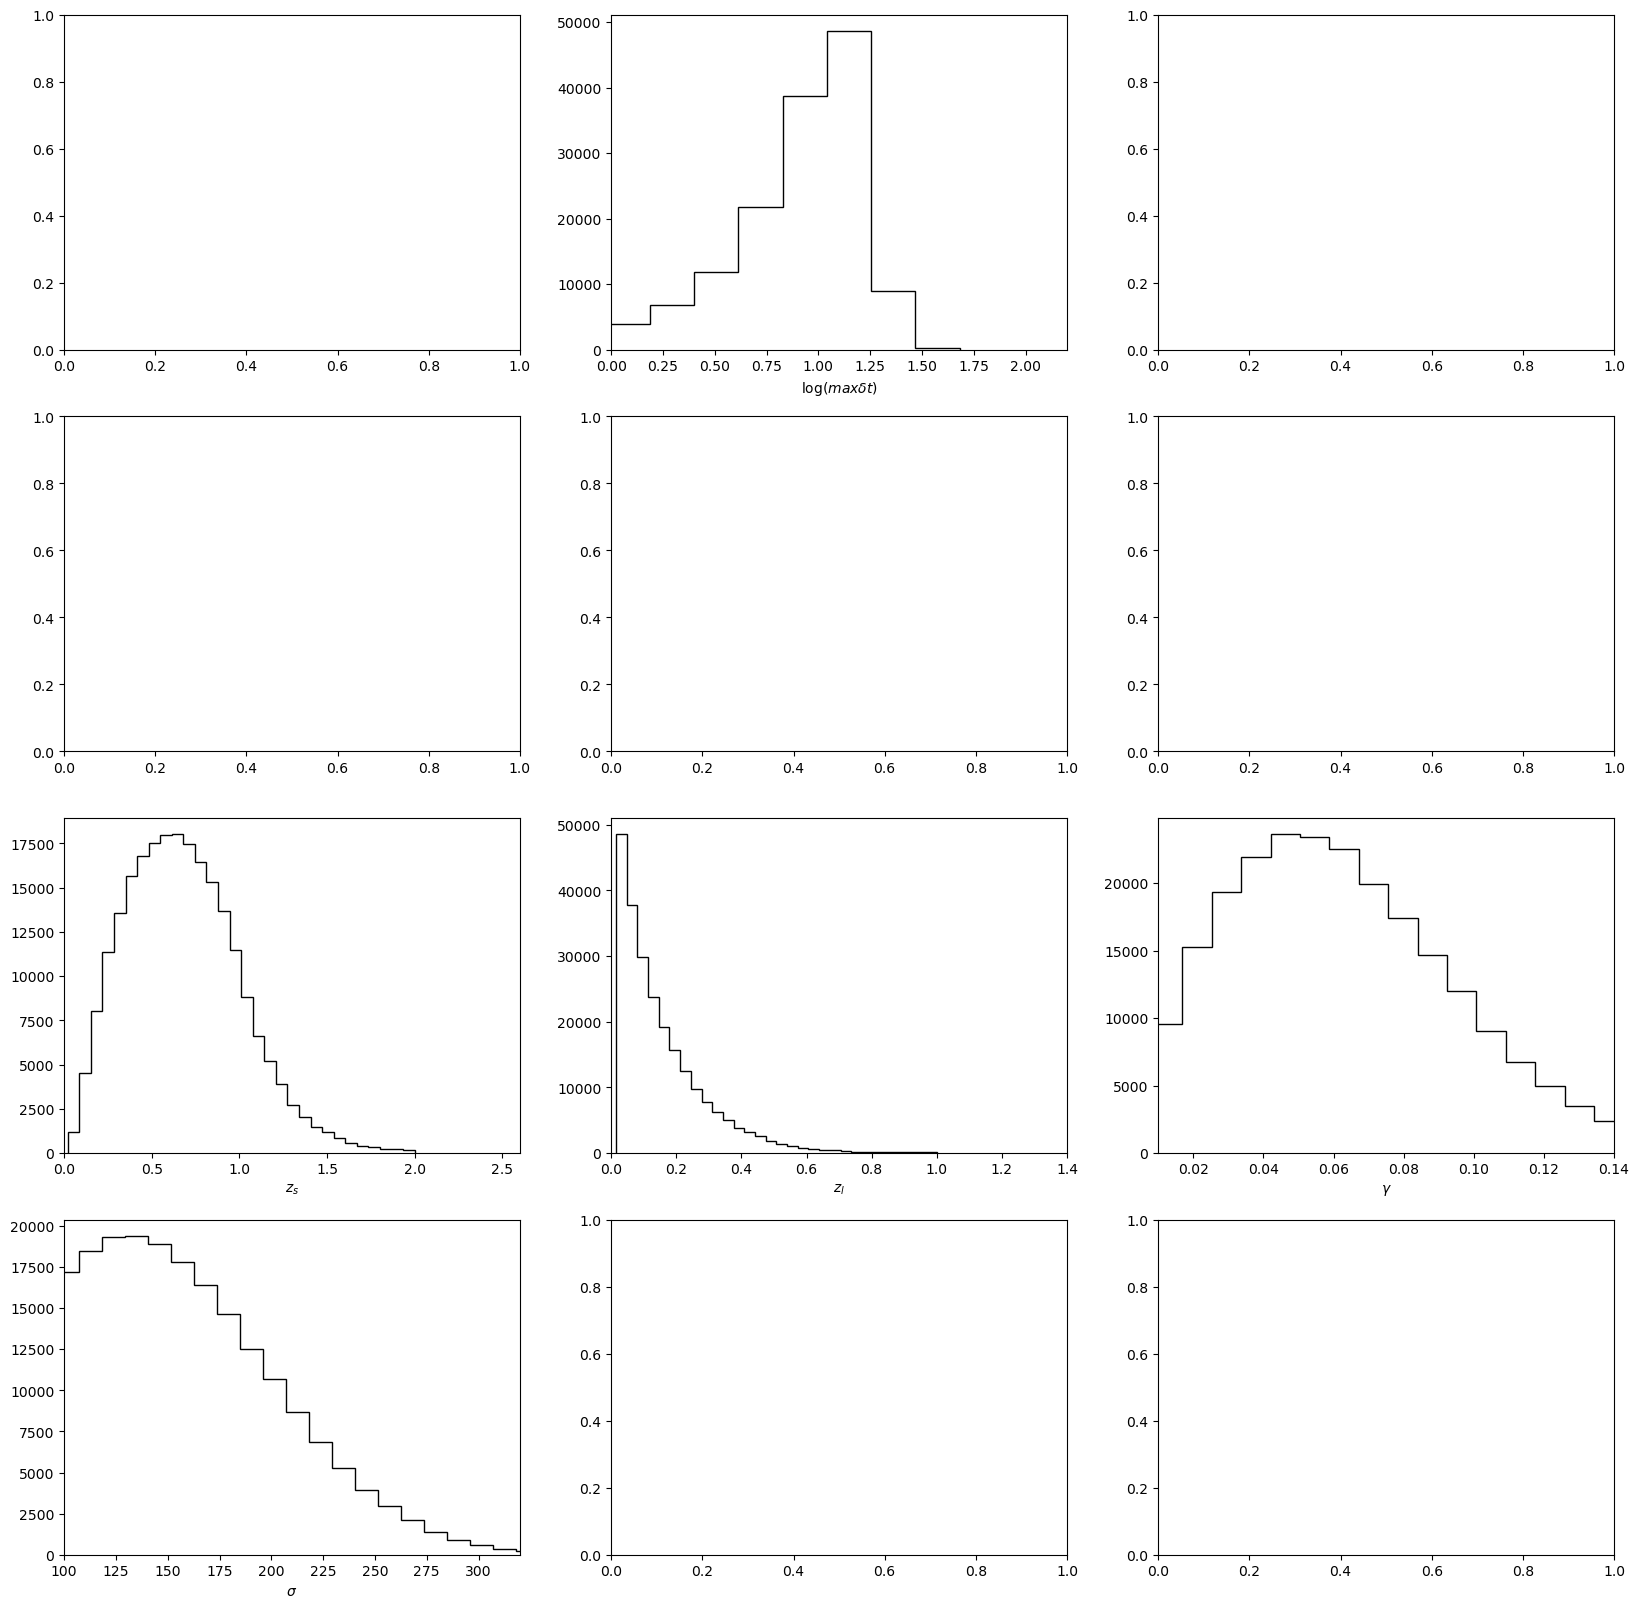

In [59]:
delta_t = t0 - t_found
delta_t_pos = delta_t[delta_t > 0] 

n_bins = 30

fig, ax = plt.subplots(4, 3, figsize = (20, 20))

ax[0][1].hist(np.log10(delta_t_pos), histtype='step', color='black', bins = n_bins)
ax[0][1].set_xlim(0, 2.2)
ax[0][1].set_xlabel(r'$\log(max\delta t)$')

ax[2][0].hist(zs, histtype='step', color='black', bins = n_bins)
ax[2][0].set_xlim(0, 2.6)
ax[2][0].set_xlabel(r'$z_s$')
ax[2][1].hist(zl, histtype='step', color='black', bins = n_bins)
ax[2][1].set_xlim(0, 1.4)
ax[2][1].set_xlabel(r'$z_l$')
ax[2][2].hist(gamma, histtype='step', color='black', bins = n_bins)
ax[2][2].set_xlim(0.01, 0.14)
ax[2][2].set_xlabel(r'$\gamma$')

ax[3][0].hist(sigma, histtype='step', color='black', bins = n_bins)
ax[3][0].set_xlabel(r'$\sigma$')
ax[3][0].set_xlim(100, 320)

plt.show()


# counts, bin_edges = np.histogram(np.log(delta_t_pos), bins=n_bins)
# peak_index = np.argmax(counts)
# peak_bin_center = 0.5 * (bin_edges[peak_index] + bin_edges[peak_index + 1])

# print(f"Peak time delay (t0 - t_found): {peak_bin_center:.2f} days")
# print(f"Median time delay (t0 - t_found): {np.median(delta_t)} days")

In [96]:
f = h5py.File('lsst-altsched-1a-lowz.h5','r')
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
simdataall = f['system']['block0_values'][()]
# print(simdataall[0],simitems)
rtest_source = [0.944,0.766, 0.678, 0.967, 0.717]
rtest_lens = [0.410, 0.396, 0.344, 0.680, 0.056]

rtest_delay = [11.36, 9.07, 20.28, 1.82, 3.06]
t0 = simdataall[:,0]
t_found = simdataall[:,31]
delta_t= t0 - t_found

#This is where I match to that table I provided by redshift. You'll want to replace this with a search for the time delay parameter and match by that!
indcatalog =[]
for i in range(5):
    indD = np.argwhere((np.abs(rtest_delay[i]-delta_t)<0.0005))
    if i==0:
        indcatalog=indD[:,0]
    else:
        indcatalog = np.hstack((indcatalog,indD[:,0]))


for ind in indcatalog:
    simdata=simdataall[ind]
    z_lens = simdata[simitems == "zl"][0]
    z_source = simdata[simitems == "zs"][0]
    t0 = simdata[simitems == "t0"][0]
    t_found = simdata[simitems == "t_found"][0] 
    delta_t = t0 - t_found
    print('z lens',z_lens,'z source',z_source, 'delay', delta_t)
    kwargs_model_time_var = {'lens_model_list': ['SIE', 'SHEAR'],  # list of lens models to be used
                'lens_light_model_list': ['SERSIC_ELLIPSE'],  # list of unlensed light models to be used
                'source_light_model_list': ['SERSIC_ELLIPSE'],#['INTERPOL'],  # list of extended source models to be used, here we used the interpolated real galaxy
                'point_source_model_list': ['SOURCE_POSITION'],  # list of point source models to be used
                'z_lens': z_lens, 
                         'z_source': z_source
    } 

z lens 0.015758718593618597 z source 0.6443332743622605 delay 11.359943006224057
z lens 0.1301279057923341 z source 0.6862473051361809 delay 11.359867051563924
z lens 0.3602183886221359 z source 0.75723054034934 delay 11.35997491026501
z lens 0.18213841952234033 z source 0.7873539838670349 delay 11.359741754917195
z lens 0.1262734219320787 z source 0.36286994161628416 delay 11.360307218412345
z lens 0.06303141999719805 z source 0.1618051941290023 delay 11.360282807181648
z lens 0.04101079596164298 z source 0.9269601437344079 delay 11.359719428583048
z lens 0.18203496141813535 z source 0.5875775056585228 delay 11.359545523657289
z lens 0.15519136637602315 z source 0.8949353290832482 delay 11.360001165332505
z lens 0.043680265722722704 z source 0.08740040529564777 delay 11.36037825664971
z lens 0.09929989247752978 z source 0.30742169452913337 delay 11.360287212359253
z lens 0.12620617960329528 z source 0.5003966728675239 delay 11.359780036444135
z lens 0.16060759297678306 z source 0.7890

## Original h5py reading code

In [ ]:
# f = h5py.File('/home/cw1074/SNsims/lsst-altsched-1a-lowz.h5','r')
f = h5py.File('lsst-altsched-1a-lowz.h5','r')
simitems = np.asarray(f['system']['block0_items'][()],dtype=str)
simdataall = f['system']['block0_values'][()]
ind = 1568 #Pull details of 1568th source
simdata=simdataall[ind]
z_lens = simdata[simitems == "zl"][0]                                 
z_source = simdata[simitems == "zs"][0]
Dl = cosmo.angular_diameter_distance(simdata[simitems == "zl"][0]).value
Ds = cosmo.angular_diameter_distance(simdata[simitems == "zs"][0]).value
Dls = cosmo.angular_diameter_distance_z1z2(simdata[simitems == "zl"][0],simdata[simitems == "zs"][0]).value
theta_E_sim = simdata[simitems == "theta_e"][0]
lens_reff = simdata[simitems == "lensgal_reff"][0]
lens_n = simdata[simitems == "lensgal_n"][0]
lens_theta = simdata[simitems == "lensgal_theta"][0]
lens_ellip = simdata[simitems == "lensgal_ellip"][0]
s = galsim.Shear(e=lens_ellip, beta=lens_theta*galsim.degrees)
lens_e1 = s.e1
lens_e2 = s.e2
lens_gamma = simdata[simitems == "gamma"][0]
gamma_theta = simdata[simitems == "theta_gamma"][0]
lens_g1 = np.sin(gamma_theta*np.pi/180)*lens_gamma
lens_g2 = np.cos(gamma_theta*np.pi/180)*lens_gamma
lens_x = simdata[simitems == "lensgal_x"][0]
lens_y = simdata[simitems == "lensgal_y"][0]

host_reff = simdata[simitems == "host_reff"][0]
host_n = simdata[simitems == "host_n"][0]
host_theta = simdata[simitems == "host_theta"][0]
host_ellip = simdata[simitems == "host_ellip"][0]
sh = galsim.Shear(e=host_ellip, beta=host_theta*galsim.degrees)

host_e1 = sh.e1#np.sin(lens_theta*np.pi/180)
host_e2 = sh.e2#np.cos(lens_theta*np.pi/180)
host_x = simdata[simitems == "host_x"][0]
host_y = simdata[simitems == "host_y"][0]
sn_x = simdata[simitems == "snx"][0]
sn_y = simdata[simitems == "sny"][0]

#Making up my own magnitudes for now, for visualization purposes
kwargs_lens = [
    {'theta_E': theta_E_sim, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y},  # SIE model
    {'gamma1': lens_g1, 'gamma2': lens_g2, 'ra_0': 0, 'dec_0': 0}  # SHEAR model
]
# lens light
kwargs_lens_light_mag_g = [{'magnitude': 24, 'R_sersic': lens_reff, 'n_sersic': lens_n, 'e1': lens_e1, 'e2': lens_e2, 'center_x': lens_x, 'center_y': lens_y}]
# source light
kwargs_source_mag_g = [{'magnitude': 23, 'R_sersic': host_reff, 'n_sersic': host_n, 'e1': host_e1, 'e2': host_e2, 'center_x': host_x, 'center_y': host_y}]

# point source
kwargs_ps_mag_g = [{'magnitude': 23, 'ra_source': sn_x, 'dec_source': sn_y}]